R Prescriptive Analytics - 3/25/2026 - April Taylor

In [1]:
#Libraries required
library(readxl)
library(dplyr)
library(randomForest)
library(ggplot2)

#Read dataset from excel file
df <- read_excel("C:\\Files\\Excel\\Prescriptive_PythonR\\AirbnbListings_v4.xlsx")

#Columns that should be treated as numeric
cols <- c("price", "minimum_nights", "number_of_reviews", "availability_365")

#Convert selected columns to numeric and remove rows with missing price values
df <- df %>%
    mutate(across(all_of(cols), as.numeric)) %>%
    filter(!is.na(price))

#Display first few rows
head(df)

#Summary statistics for all columns
summary(df)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:dplyr':

    combine



Attaching package: 'ggplot2'


The following object is masked from 'package:randomForest':

    margin




id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
9.20345e+17,519861666,Christie,Near East,Entire home/apt,316,1,0,364
9.15221e+17,519861666,Christie,Near North/University,Entire home/apt,107,1,0,363
9.13158e+17,519861666,Christie,Near East,Entire home/apt,117,1,0,362
8.73543e+17,510891891,Mjm,Near South,Entire home/apt,212,2,3,329
8.73536e+17,510891891,Mjm,Near South,Entire home/apt,174,2,3,360
8.66927e+17,509496983,Ray,Near South,Entire home/apt,109,1,4,351


       id               host_id           host_name         neighbourhood     
 Min.   :9.068e+04   Min.   :    78761   Length:2399        Length:2399       
 1st Qu.:4.657e+07   1st Qu.: 63566473   Class :character   Class :character  
 Median :6.102e+17   Median :175883174   Mode  :character   Mode  :character  
 Mean   :4.295e+17   Mean   :213127182                                        
 3rd Qu.:7.826e+17   3rd Qu.:353852822                                        
 Max.   :9.212e+17   Max.   :519861666                                        
  room_type             price        minimum_nights    number_of_reviews
 Length:2399        Min.   :  17.0   Min.   :  1.000   Min.   :  0.00   
 Class :character   1st Qu.:  80.0   1st Qu.:  1.000   1st Qu.:  4.00   
 Mode  :character   Median : 112.0   Median :  2.000   Median : 17.00   
                    Mean   : 142.8   Mean   :  6.882   Mean   : 49.71   
                    3rd Qu.: 169.0   3rd Qu.:  2.000   3rd Qu.: 60.00   
         

In [2]:
#Select the predictor variables to include in the model
features <- c("minimum_nights", "number_of_reviews", "availability_365")

#Subset the dataframe into feature matrix and target vector
X <- df[, features]
Y <- df$price

#Train a Random Forest regression model with feature importance enbaled
model <- randomForest(X, Y, importance = TRUE)

#Display the importance scores for each predictor variable
importance(model)


,%IncMSE,IncNodePurity
minimum_nights,38.67529,3268479
number_of_reviews,24.98658,4163011
availability_365,15.45587,5007000


<theme> List of 144
 $ line                            : <ggplot2::element_line>
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ lineend      : chr "butt"
  ..@ linejoin     : chr "round"
  ..@ arrow        : logi FALSE
  ..@ arrow.fill   : chr "black"
  ..@ inherit.blank: logi TRUE
 $ rect                            : <ggplot2::element_rect>
  ..@ fill         : chr "white"
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ linejoin     : chr "round"
  ..@ inherit.blank: logi TRUE
 $ text                            : <ggplot2::element_text>
  ..@ family       : chr ""
  ..@ face         : chr "plain"
  ..@ italic       : chr NA
  ..@ fontweight   : num NA
  ..@ fontwidth    : num NA
  ..@ colour       : chr "black"
  ..@ size         : num 11
  ..@ hjust        : num 0.5
  ..@ vjust        : num 0.5
  ..@ angle        : num 0
  ..@ lineheight   : num 0.9
  ..@ margin       : <ggplot2::margin> nu

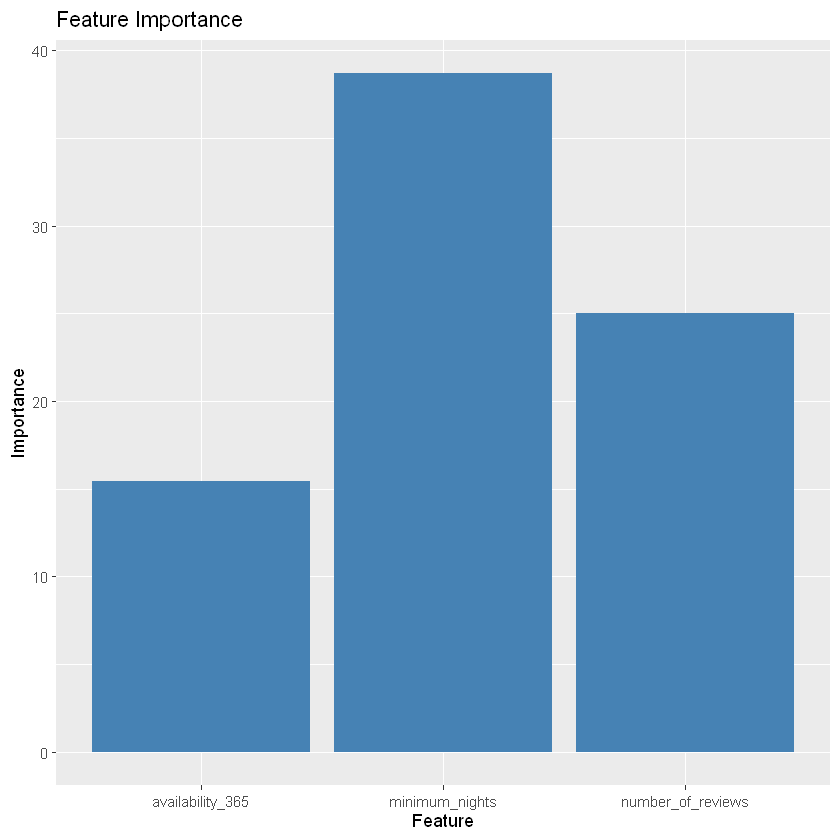

In [3]:
#Create a data frame containing each feature name and its importance score
imp <- data.frame(
    Feature = rownames(importance(model)),
    Importance = importance(model)[, 1]
)

#Generate a bar plot visualizating feature importance values
ggplot(imp, aes(x = Feature, y = Importance)) + 
    geom_bar(stat = "identity", fill = "steelblue") +
    ggtitle("Feature Importance")
    theme_minimal()


Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information."


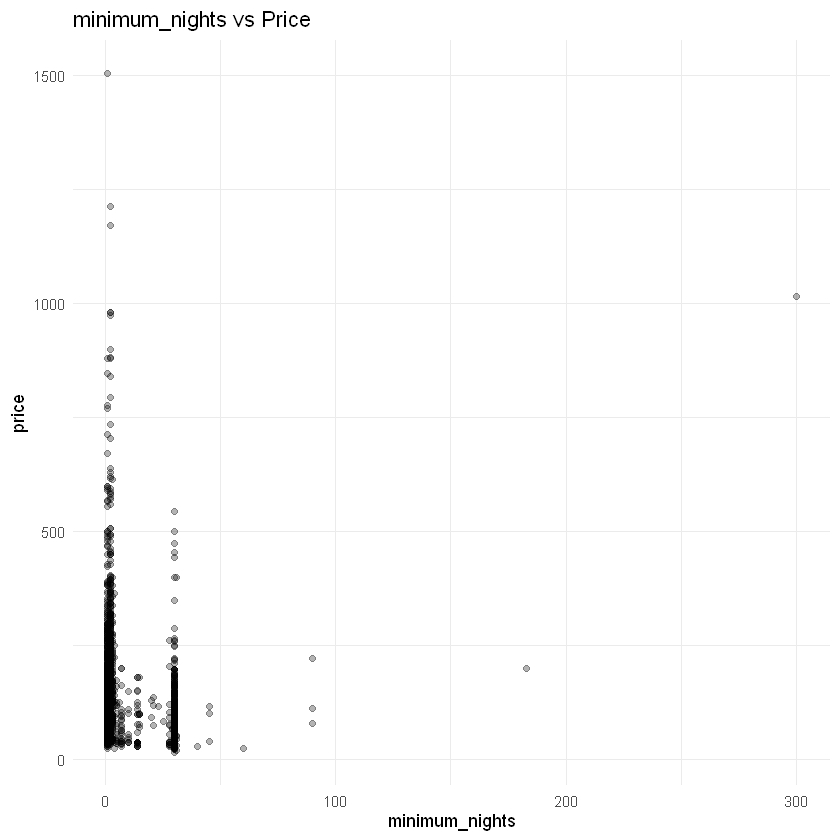

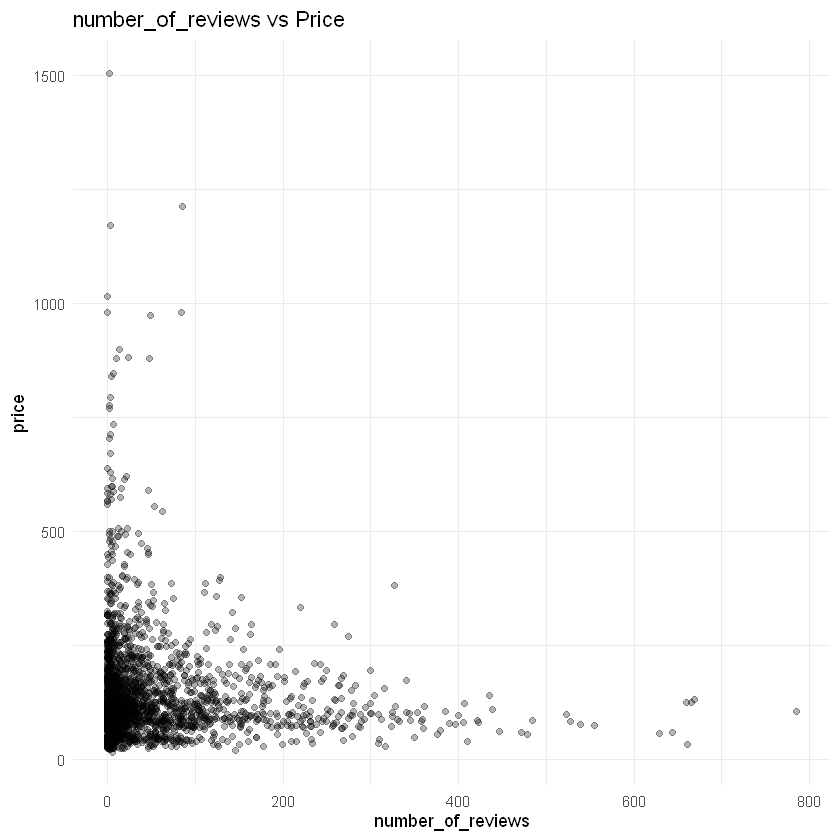

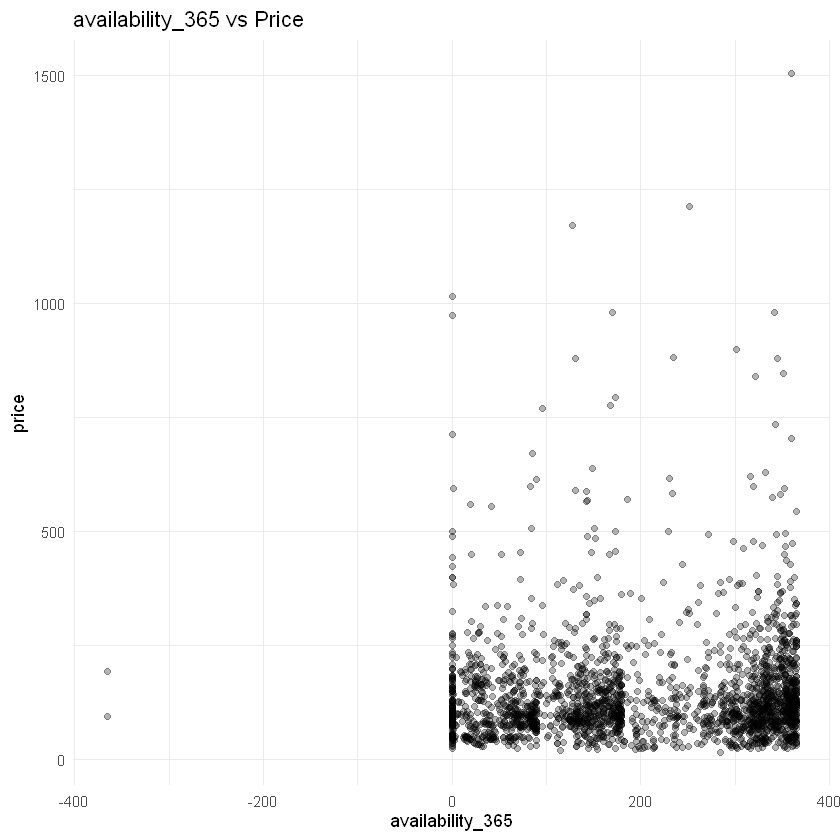

In [4]:
#Loop through each selected feature to generate scatter plots
for (col in features) {
    print(
        ggplot(df,aes_string(x = col, y = "price")) +
        geom_point(alpha = 0.3) +
        ggtitle(paste(col, "vs Price")) +
        theme_minimal()
    )
}

In [5]:
#Generate predicted prices using the trained model
df$predicted_price <- predict(model, X)

#Identify the row with the highest predicted prices
best_index <- which.max(df$predicted_price)
best_row <- df[best_index, ]

#Display the feature values for the top predicted listing
best_row[features]

#Display the model's predicted price for that listing
best_row$predicted_price


minimum_nights,number_of_reviews,availability_365
<dbl>,<dbl>,<dbl>
300,0,0


702 
605.7292

In [6]:
#Function to test how changing one feature will affect the predicted price
what_if_change <- function(feature, amount) {
    temp <- best_row[, features]
    temp[[feature]] <- temp[[feature]] + amount
    predict(model, temp)[1]
}

#Run several what-if scenarios to see how feature changes influence the model's prediction
what_if_change("minimum_nights", 14)
what_if_change("availability_365", 50)
what_if_change("number_of_reviews", 30)

1 
605.7292

1 
507.2818

1 
475.6789

In [7]:
#Function that predicts the price for a custom scenario
predict_scenario <- function(min_nights, reviews, avail) {
    newdata <- data.frame(
        minimum_nights = as.numeric(min_nights),
        number_of_reviews = as.numeric(reviews),
        availability = as.numeric(avail)
    )
    colnames(newdata) <- features
    predict(model, newdata)[1]
}

#List of custom scenarios to evaluate using the model
scenarios <- list(
    c(as.numeric(7), as.numeric(100), as.numeric(best_row$availability_365)),
    c(as.numeric(1), as.numeric(10), as.numeric(best_row$availability_365)),
    c(as.numeric(2), as.numeric(best_row$number_of_reviews), as.numeric(100)),
    c(as.numeric(14), as.numeric(best_row$number_of_reviews), as.numeric(300)),
    c(as.numeric(best_row$minimum_nights), as.numeric(5), as.numeric(300)),
    c(as.numeric(best_row$minimum_nights), as.numeric(200), as.numeric(100))
)

#Loop through each scenario and print the predicted price
for (s in scenarios) {
    cat("Scenario:", paste(s, collapse = ", "),
        "Predicted Price:", predict_scenario(s[1], s[2], s[3]), "\n")
}

Scenario: 7, 100, 0 Predicted Price: 105.7641 
Scenario: 1, 10, 0 Predicted Price: 142.5199 
Scenario: 2, 0, 100 Predicted Price: 226.9094 
Scenario: 14, 0, 300 Predicted Price: 92.56774 
Scenario: 300, 5, 300 Predicted Price: 365.2621 
Scenario: 300, 200, 100 Predicted Price: 270.6317 
